In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/Cinema_Audience_Forecasting_challenge/movie_theater_id_relation/movie_theater_id_relation.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/date_info/date_info.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_theaters/booknow_theaters.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_booking/cinePOS_booking.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_theaters/cinePOS_theaters.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_visits/booknow_visits.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_booking/booknow_booking.csv


In [2]:
import warnings
warnings.filterwarnings("ignore")
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [3]:
rel=pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/movie_theater_id_relation/movie_theater_id_relation.csv")
date_info=pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/date_info/date_info.csv")
sample=pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv")
book_theater=pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_theaters/booknow_theaters.csv")
cine_bookings=pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_booking/cinePOS_booking.csv")
cine_theater=pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_theaters/cinePOS_theaters.csv")
book_vis=pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_visits/booknow_visits.csv")
book_bookings=pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_booking/booknow_booking.csv")

## **EDA**

### **1.1 Booknow_bookings**

In [4]:
print(book_bookings.shape)
print(book_bookings.isna().sum())


(68336, 4)
book_theater_id     0
show_datetime       0
booking_datetime    0
tickets_booked      0
dtype: int64


In [5]:
print(book_bookings.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68336 entries, 0 to 68335
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   book_theater_id   68336 non-null  object
 1   show_datetime     68336 non-null  object
 2   booking_datetime  68336 non-null  object
 3   tickets_booked    68336 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 2.1+ MB
None


In [6]:
book_bookings['tickets_booked'].describe()

count    68336.000000
mean         4.425808
std          4.808945
min          1.000000
25%          2.000000
50%          3.000000
75%          5.000000
max        100.000000
Name: tickets_booked, dtype: float64

In [7]:
book_bookings['show_datetime'] = pd.to_datetime(book_bookings['show_datetime'])
book_bookings['booking_datetime'] = pd.to_datetime(book_bookings['booking_datetime'])
book_bookings['show_date'] = book_bookings['show_datetime'].dt.date
book_bookings['show_date'] = pd.to_datetime(book_bookings['show_date'])


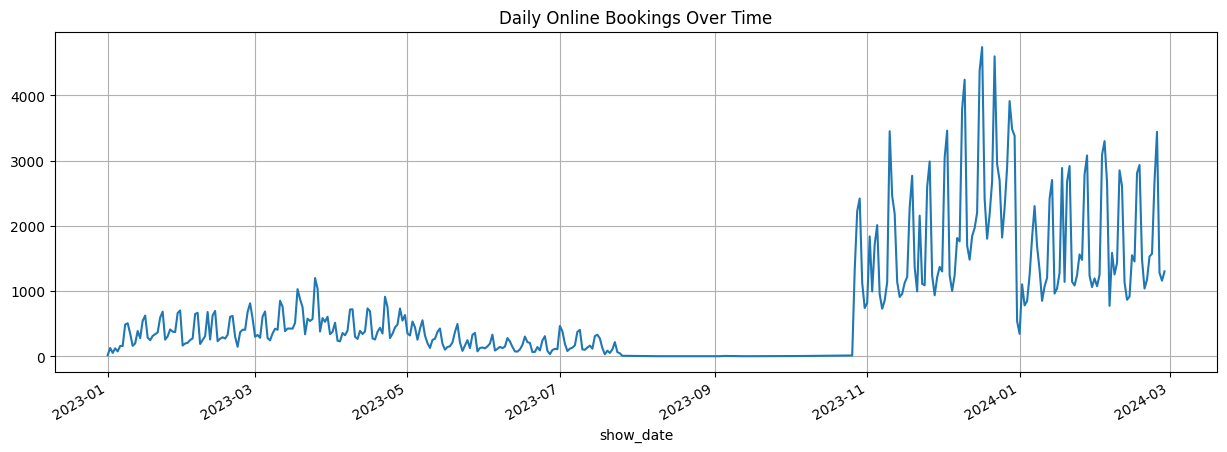

In [8]:
daily = book_bookings.groupby('show_date')['tickets_booked'].sum()
plt.figure(figsize=(15,5))
daily.plot()
plt.title("Daily Online Bookings Over Time")
plt.grid(True)

In [9]:
book_bookings['weekday'] = book_bookings['show_date'].dt.day_name()
weekday = book_bookings.groupby('weekday')['tickets_booked'].mean()
print(weekday)

weekday
Friday       4.524036
Monday       4.166296
Saturday     4.565089
Sunday       4.328606
Thursday     4.573675
Tuesday      4.448133
Wednesday    4.368030
Name: tickets_booked, dtype: float64


In [10]:
print(f"Data Range: {book_bookings['show_datetime'].min()} -> {book_bookings['show_datetime'].max()}")
print(f"Data Range: {book_bookings['booking_datetime'].min()} -> {book_bookings['booking_datetime'].max()}")

Data Range: 2023-01-01 19:00:00 -> 2024-02-28 23:00:00
Data Range: 2023-01-01 01:00:00 -> 2024-02-28 22:00:00


In [11]:
book_bookings['lead_time'] = (book_bookings['show_datetime'] - book_bookings['booking_datetime'])
print(book_bookings['lead_time'].describe())

count                         68336
mean      9 days 01:54:02.454928588
std      29 days 03:19:42.147306581
min               -1 days +18:00:00
25%                 0 days 05:00:00
50%                 2 days 02:00:00
75%                 7 days 21:00:00
max               392 days 03:00:00
Name: lead_time, dtype: object


### **1.2 cinePOS_booking**

In [12]:
print(cine_bookings.shape)
print(cine_bookings.isna().sum())


(1641966, 4)
cine_theater_id     0
show_datetime       0
booking_datetime    0
tickets_sold        0
dtype: int64


In [13]:
print(cine_bookings.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1641966 entries, 0 to 1641965
Data columns (total 4 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   cine_theater_id   1641966 non-null  object
 1   show_datetime     1641966 non-null  object
 2   booking_datetime  1641966 non-null  object
 3   tickets_sold      1641966 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 50.1+ MB
None


In [14]:
cine_bookings['show_datetime'] = pd.to_datetime(cine_bookings['show_datetime'])
cine_bookings['booking_datetime'] = pd.to_datetime(cine_bookings['booking_datetime'])
cine_bookings['show_date'] = cine_bookings['show_datetime'].dt.date
cine_bookings['show_date'] = pd.to_datetime(cine_bookings['show_date'])


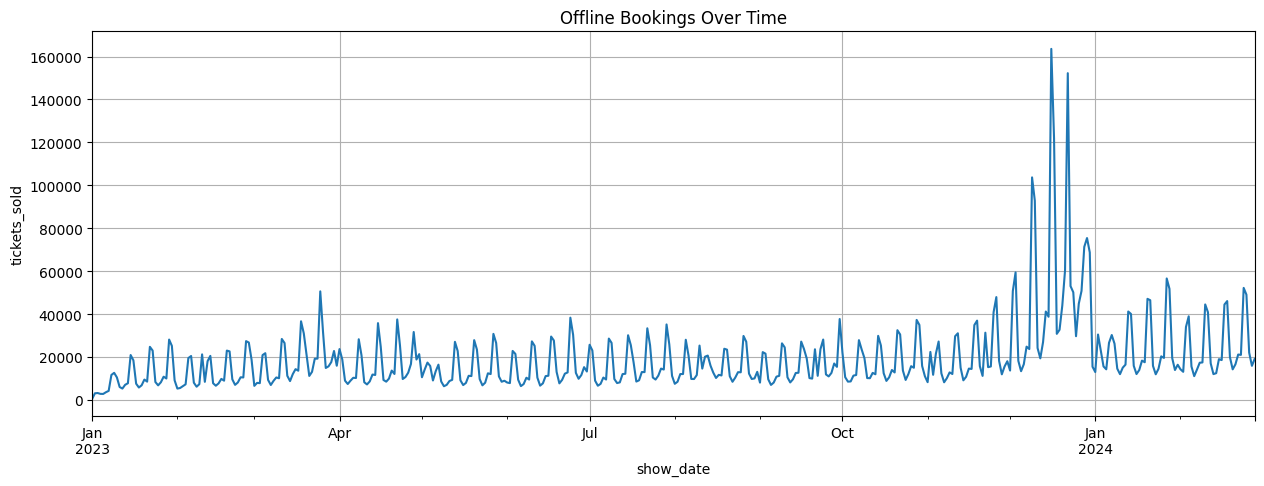

In [15]:
daily = cine_bookings.groupby('show_date')['tickets_sold'].sum()
plt.figure(figsize=(15,5))
daily.plot()
plt.title("Offline Bookings Over Time")
plt.grid(True)
plt.ylabel("tickets_sold")
plt.show()

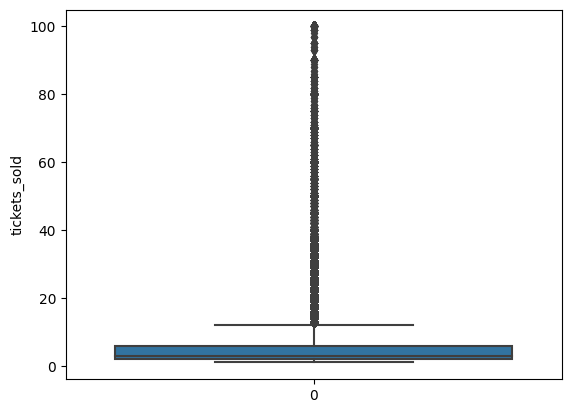

In [16]:
sns.boxplot(cine_bookings['tickets_sold'])
plt.ylabel('tickets_sold')
plt.show()

### **1.3 Booknow_theaters**

In [17]:
print(book_theater.shape)
print(book_theater['book_theater_id'].nunique())

(829, 5)
314


In [18]:
print(book_theater.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 829 entries, 0 to 828
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   book_theater_id  314 non-null    object 
 1   theater_type     829 non-null    object 
 2   theater_area     829 non-null    object 
 3   latitude         829 non-null    float64
 4   longitude        829 non-null    float64
dtypes: float64(2), object(3)
memory usage: 32.5+ KB
None


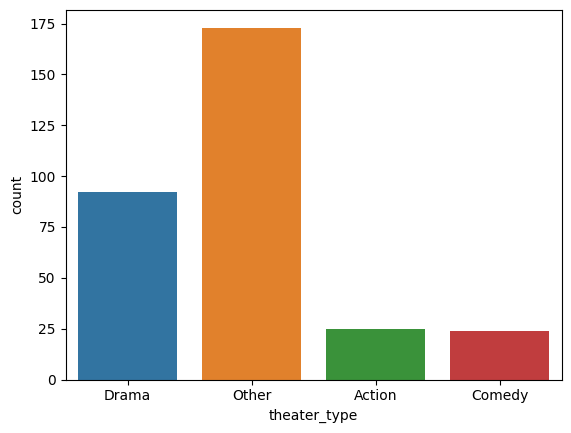

In [19]:
real_theaters = book_theater.dropna(subset=["book_theater_id"])
sns.countplot(x='theater_type', data=real_theaters)
plt.show()

71


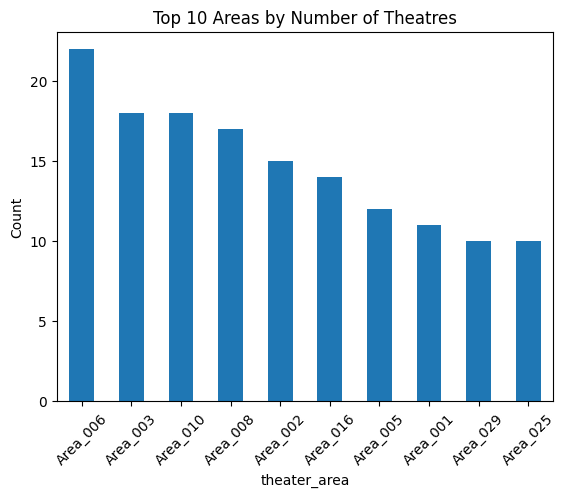

In [20]:
print(real_theaters['theater_area'].nunique())
real_theaters['theater_area'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Areas by Number of Theatres")
plt.xlabel("theater_area")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

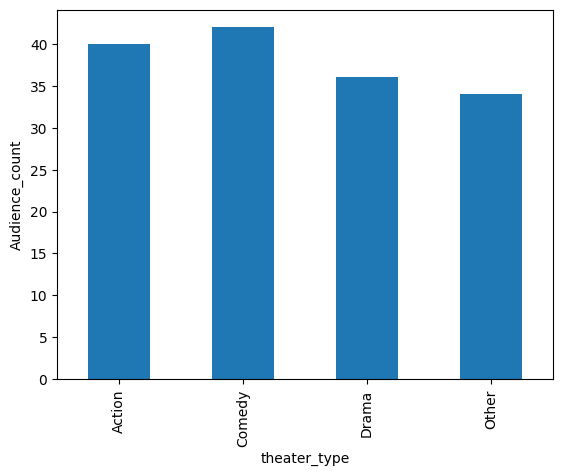

In [21]:
aud_merge = book_vis.merge(real_theaters, on='book_theater_id', how='left')
aud_merge.groupby("theater_type")['audience_count'].median().plot(kind='bar')
plt.ylabel('Audience_count')
plt.show()

### **1.4 cinePOS_theaters.csv**

In [22]:
print(cine_theater.shape)
print(cine_theater['cine_theater_id'].nunique())

(4690, 5)
4690


In [23]:
print(cine_theater.isna().sum())

cine_theater_id       0
theater_type          0
theater_area          0
latitude           3861
longitude          3861
dtype: int64


119


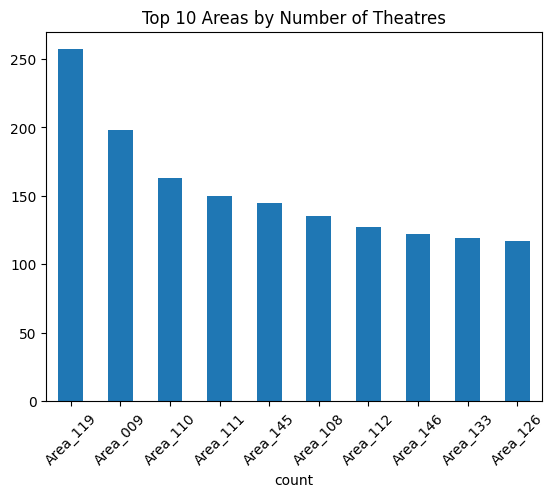

In [24]:
print(cine_theater['theater_area'].nunique())
cine_theater['theater_area'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Areas by Number of Theatres")
plt.xlabel("count")
plt.xticks(rotation=45)
plt.show()

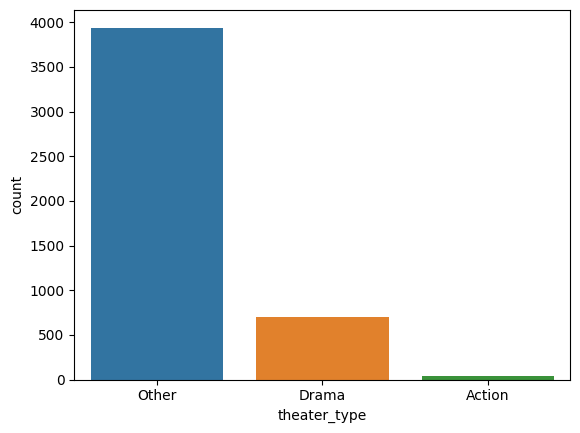

In [25]:
sns.countplot(x='theater_type', data=cine_theater)
plt.show()

### **1.5 Movie_theater_id Relation**

In [26]:
print(rel.shape)
print(rel.info())

(150, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   book_theater_id  150 non-null    object
 1   cine_theater_id  150 non-null    object
dtypes: object(2)
memory usage: 2.5+ KB
None


#### **Merging Datasets**

In [27]:
merged=book_vis.merge(rel,on=['book_theater_id'],how='left')
print(merged.isna().sum())
merged1=merged.merge(book_theater,on=['book_theater_id'],how='left')

book_theater_id         0
show_date               0
audience_count          0
cine_theater_id    175070
dtype: int64


In [28]:
print(merged1.isna().sum())

book_theater_id         0
show_date               0
audience_count          0
cine_theater_id    175070
theater_type       133896
theater_area       133896
latitude           133896
longitude          133896
dtype: int64


### **1.6 Book_now visits**

In [29]:
print(book_vis.shape)
print(book_vis['book_theater_id'].nunique())
print(f"Data Range: {book_vis['show_date'].min()} -> {book_vis['show_date'].max()}")

(214046, 3)
826
Data Range: 2023-01-01 -> 2024-02-28


In [30]:
book_vis['audience_count'].describe()

count    214046.000000
mean         41.616568
std          32.834918
min           2.000000
25%          18.000000
50%          34.000000
75%          58.000000
max        1350.000000
Name: audience_count, dtype: float64

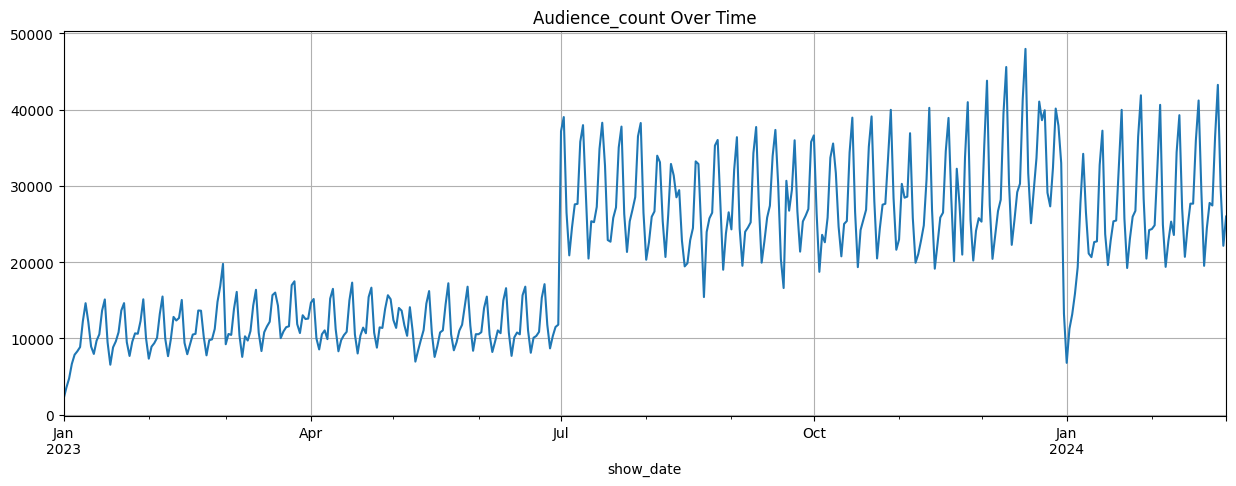

In [31]:
book_vis['show_date']=pd.to_datetime(book_vis['show_date'])

book_vis=book_vis.groupby(['book_theater_id','show_date'])['audience_count'].sum().reset_index()

daily = book_vis.groupby('show_date')['audience_count'].sum()
plt.figure(figsize=(15,5))
daily.plot()
plt.title("Audience_count Over Time")
plt.grid(True)

In [32]:
# Top 5 Theaters
theater_count=book_vis.groupby('book_theater_id')['audience_count'].sum().reset_index().sort_values(by='audience_count',ascending=False)

In [33]:
theater_count.head()

,book_theater_id,audience_count
115,book_00117,34256
660,book_00664,33066
585,book_00589,32882
699,book_00703,32714
677,book_00681,32226


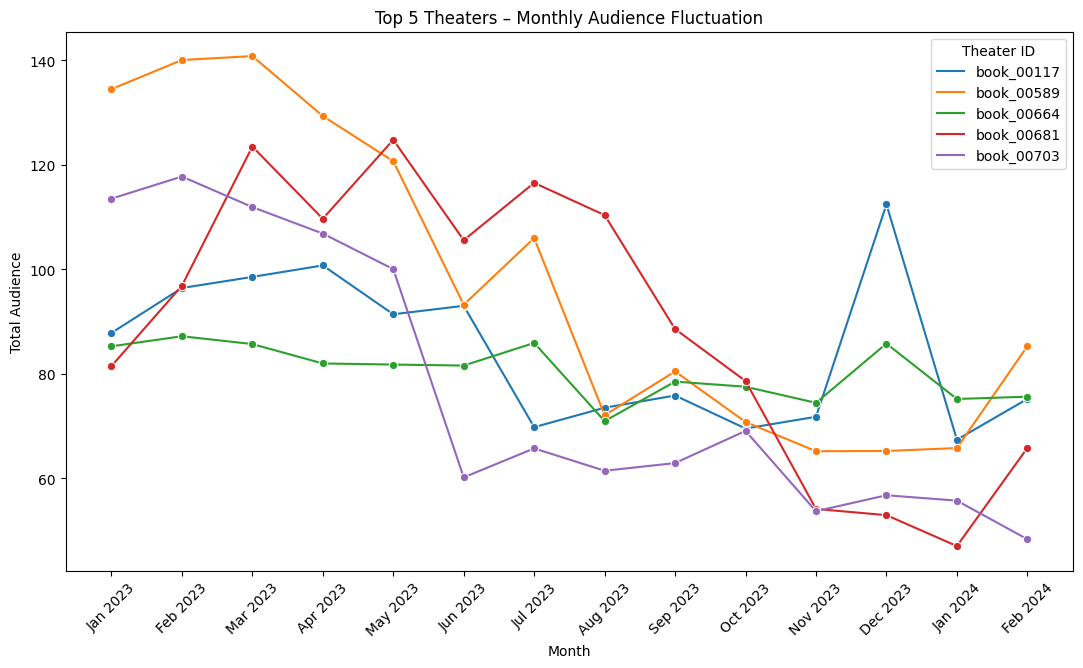

In [34]:
top_5_data=book_vis[book_vis['book_theater_id'].isin(theater_count.head()['book_theater_id'])]
top_5_data['year_month']=top_5_data['show_date'].dt.strftime('%b %Y')

plt.figure(figsize=(13, 7))
sns.lineplot(data=top_5_data,x='year_month',y='audience_count',hue='book_theater_id',marker='o',errorbar=None)
plt.title('Top 5 Theaters – Monthly Audience Fluctuation')
plt.xlabel('Month')
plt.ylabel('Total Audience')
plt.legend(title='Theater ID')
plt.xticks(rotation=45)
plt.show()


In [35]:
holiday_dates = [ "2023-01-22",  "2023-02-05",  "2023-02-15",  "2023-02-18",  "2023-02-26", "2023-03-08",  "2023-03-11",  "2023-03-30",  
    "2023-04-04",  "2023-04-07",  "2023-04-14",  "2023-04-22",  "2023-05-05",  "2023-06-29",  "2023-07-29",  "2023-08-15",  "2023-09-07",  
    "2023-09-28",  "2023-10-02", "2023-10-24",  "2023-11-12",  "2023-11-27",  "2023-12-25", "2024-01-17",  "2024-01-26",  "2024-02-12",  
    "2024-02-14",  "2024-02-24",  "2024-02-26",  "2024-03-08",  "2024-03-25",  "2024-03-29","2024-04-11",  "2024-04-14",  "2024-04-17"]

holidays=pd.to_datetime(holiday_dates).date
book_vis['is_holiday']=book_vis['show_date'].dt.date.isin(holidays).astype(int)


### **2 Feature Engneering**

In [36]:
# Grouping theaters based on Clusters

pivot=book_vis.pivot(index='book_theater_id',columns='show_date',values='audience_count').fillna(0)
x_pca=PCA(n_components=15).fit_transform(pivot)
clusters=KMeans(n_clusters=6,n_init=10,random_state=42).fit_predict(x_pca)
book_vis['cluster']=book_vis['book_theater_id'].map(dict(zip(pivot.index,clusters)))

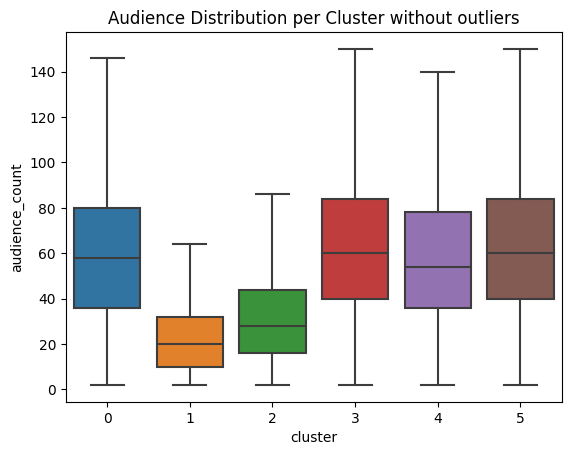

In [37]:
sns.boxplot(x='cluster', y='audience_count', data=book_vis,showfliers=False)
plt.title("Audience Distribution per Cluster without outliers")
plt.show()

In [38]:
# Target Encoding
theater_stats = (
    book_vis.groupby('book_theater_id')['audience_count']
      .agg(['median', 'std', 'count'])
      .rename(columns={'median': 'theater_median_audience',
                       'std': 'theater_std_audience',
                       'count': 'theater_num_obs'})
)
book_vis = book_vis.merge(theater_stats, on='book_theater_id', how='left')

In [39]:
#setting show date as index
book_vis=book_vis.set_index('show_date')
book_vis.index=pd.to_datetime(book_vis.index)
book_vis=book_vis.sort_index()

In [40]:
# Creation of time features
def Create_features(df):
    df=df.copy()
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    df['dayofmonth'] = df.index.day
    df['weekofyear'] = df.index.isocalendar().week
    df['is_weekend']=df['dayofweek'].isin([5,6]).astype(int)
    return df
    
df=Create_features(book_vis)

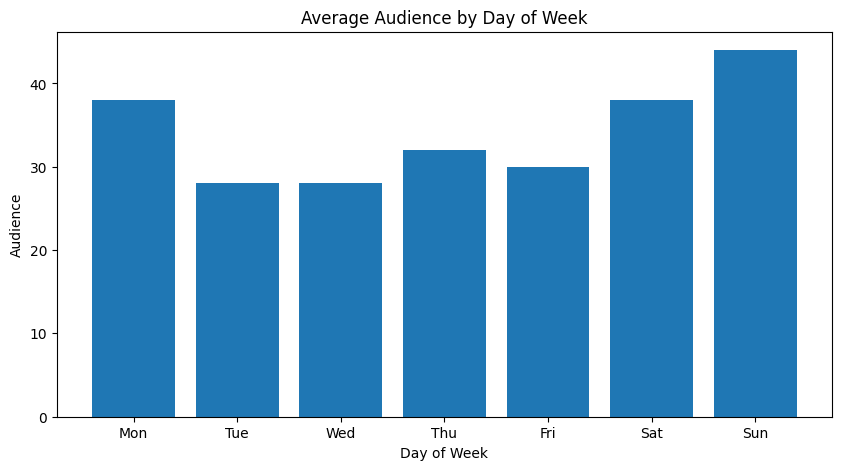

In [41]:
weekday_avg=df.groupby('dayofweek')['audience_count'].median()
plt.figure(figsize=(10,5))
plt.bar(weekday_avg.index, weekday_avg.values)
plt.xticks(
    ticks=[0,1,2,3,4,5,6],
    labels=["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
)
plt.title("Average Audience by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Audience")
plt.show()

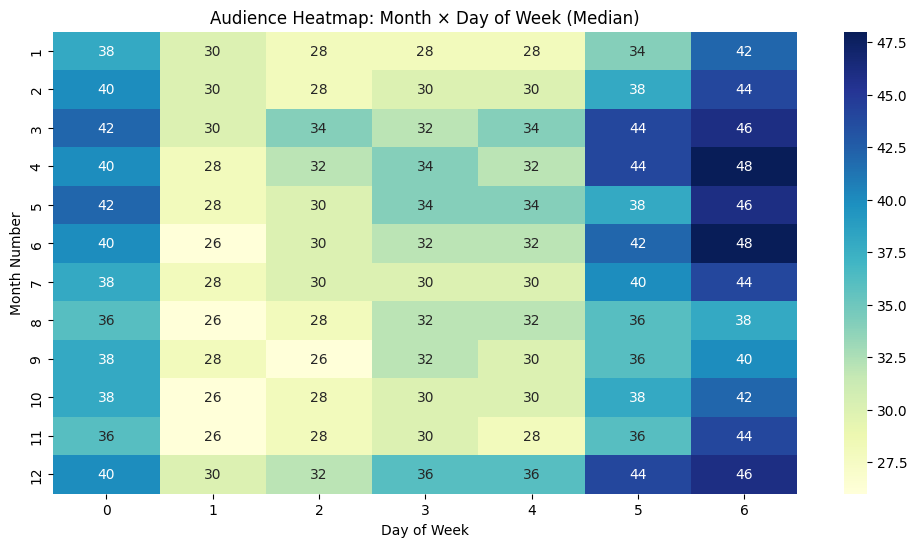

In [42]:
pivot = df.pivot_table(values='audience_count',index='month',columns='dayofweek',aggfunc='median') 
plt.figure(figsize=(12, 6))
sns.heatmap(pivot, annot=True,cmap="YlGnBu")
plt.title("Audience Heatmap: Month × Day of Week (Median)")
plt.xlabel("Day of Week")
plt.ylabel("Month Number")
plt.show()

In [43]:
#Cyclic encoding
def cyclic_encoding(df):
    df=df.copy()
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['dayofweek_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['dayofweek_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)
    df['dayofyear_sin'] = np.sin(2 * np.pi * df['dayofyear'] / 365)
    df['dayofyear_cos'] = np.cos(2 * np.pi * df['dayofyear'] / 365)
    df['weekofyear_sin'] = np.sin(2 * np.pi * df['weekofyear'] / 52)
    df['weekofyear_cos'] = np.cos(2 * np.pi * df['weekofyear'] / 52)
    df['quarter_sin'] = np.sin(2 * np.pi * df['quarter'] / 4)
    df['quarter_cos'] = np.cos(2 * np.pi * df['quarter'] / 4)
    df.drop(['dayofweek','month','dayofyear','weekofyear','quarter'], axis=1, inplace=True)
    
    return df
    
df=cyclic_encoding(df)    

In [44]:
# By days
def add_lags(df, id_col,target_col,lags):
    df = df.copy()
    
    for lag in lags:
        df[f'lag_{lag}'] = np.nan

    for tid, group in df.groupby(id_col):
        targetmap = group[target_col].to_dict()
        for lag in lags:
            shiftedind = group.index - pd.Timedelta(days=lag)
            mask = df[id_col] == tid
            df.loc[mask, f'lag_{lag}'] = shiftedind.map(targetmap).values
    return df
    
# By observations   
def add_lags1(df, id_col,target_col,lags):
    df = df.sort_values(['book_theater_id', df.index.name])
    for lag in lags:
        df[f'lag_{lag}'] = df.groupby(id_col)[target_col].shift(lag)
    return df
    
concat_df=df.copy()

df=add_lags(df,'book_theater_id','audience_count',lags=[60,65,70])

###  **3 Splitting Data**

In [45]:
df=df.sort_index()

train=df.loc[df.index< "01-01-2024"]
test=df.loc[df.index>= "01-01-2024"]

In [46]:
features=['theater_median_audience','theater_std_audience','theater_num_obs','month_sin','month_cos','year','quarter_sin','quarter_cos','dayofmonth','dayofyear_sin','dayofyear_cos','dayofweek_sin','dayofweek_cos','weekofyear_sin','weekofyear_cos','is_holiday','is_weekend','cluster','lag_60','lag_65','lag_70']
target= 'audience_count'

# creation of training and test set
x_train=train[features]
y_train=train[target]

x_test=test[features]
y_test=test[target]

### **4 Models Creation**

## Model1

In [47]:

pipe = Pipeline([('xgb', xgb.XGBRegressor(n_estimators=1000,learning_rate=0.05,objective='count:poisson',random_state=42,n_jobs=-1))])
pipe.fit(x_train,y_train)


y_pred = pipe.predict(x_test)
y_pred = np.round(y_pred)


r2 = r2_score(y_test, y_pred)
print(r2)

0.498477467616684


In [48]:
pd.Series(y_pred).describe()

count    39511.000000
mean        44.028244
std         23.813671
min          3.000000
25%         25.000000
50%         39.000000
75%         59.000000
max        221.000000
dtype: float64

### Model2

In [49]:
rf = Pipeline([
    ('impute', SimpleImputer(strategy='constant', fill_value=0)),
    ('model', RandomForestRegressor(
        n_estimators=500,
        random_state=42,
        n_jobs=-1
    ))
])

rf.fit(x_train, y_train)

y_pred = rf.predict(x_test)
y_pred = np.round(y_pred)

print("R2:", r2_score(y_test, y_pred))

R2: 0.40549043256702433


### Model3

In [50]:
model = lgb.LGBMRegressor(n_estimators=1000,learning_rate=0.05,random_state=42,objective='poisson')

model.fit(x_train, y_train)
y_pred=model.predict(x_test)

y_pred=np.round(y_pred)
r2=r2_score(y_test,y_pred)
print(r2)     


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013355 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1678
[LightGBM] [Info] Number of data points in the train set: 174360, number of used features: 20
[LightGBM] [Info] Start training from score 3.738778
0.5102023966137974


### **5 Hyperparameter_tuning**

In [51]:
params = {
    'n_estimators': [900, 1200],
    'learning_rate': [0.05, 0.07],
    'max_depth': [5,6,7,8],
     'min_child_weight': [1,2,3,5],
    'subsample': [0.7,0.8,0.9],
    'colsample_bytree': [0.7,0.8,0.9]
}

model =  xgb.XGBRegressor(random_state=42,n_jobs=-1,objective='count:poisson')
search = RandomizedSearchCV(
   estimator=model,
   param_distributions=params,
   n_iter=20,
   scoring='neg_mean_squared_error',
   cv=2,
   verbose=1,
   random_state=42,
   n_jobs=-1)

search.fit(x_train, y_train)

print("Best Parameters:", search.best_params_)

XgbSearchModel = search.best_estimator_
print("Test R2 Score:", round(XgbSearchModel.score(x_test, y_test), 4))

Fitting 2 folds for each of 20 candidates, totalling 40 fits
Best Parameters: {'subsample': 0.7, 'n_estimators': 900, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.9}
Test R2 Score: 0.4968


### TestData Creation

In [52]:
test_df=sample.copy()

test_df['book_theater_id'] = test_df['ID'].str.split('_').str[0] + '_' + test_df['ID'].str.split('_').str[1]
test_df['show_date'] = pd.to_datetime(test_df['ID'].str.split('_').str[2])

test_df = test_df.merge(theater_stats, on='book_theater_id', how='left')


In [53]:
test_df['show_date']=pd.to_datetime(test_df['show_date'])
test_df['is_holiday']=test_df['show_date'].dt.date.isin(holidays).astype(int)

test_df['cluster']=test_df['book_theater_id'].map(dict(zip(pivot.index,clusters))).fillna(-1)

test_df=test_df.set_index('show_date')
test_df.index=pd.to_datetime(test_df.index)


In [54]:
test_df=Create_features(test_df)
test_df=cyclic_encoding(test_df)

In [55]:
concat_df['is_future']=False
test_df['is_future']=True
cf_and_future=pd.concat([concat_df,test_df])
gf_and_future=add_lags1(cf_and_future,'book_theater_id','audience_count',lags=[60,65,70])
test_df= gf_and_future.query('is_future').copy()
(test_df.shape)

(38062, 25)

In [56]:
final=df[features]

pipe.fit(final,df['audience_count'])
final_predict=pipe.predict(test_df[features])
final_predict=np.round(final_predict)

In [57]:
sample['audience_count'] = final_predict
submission=sample.copy()
submission.to_csv("/kaggle/working/submission.csv", index=False)

In [58]:
submission.describe()

,audience_count
count,38062.000000
mean,43.341705
std,22.891100
min,3.000000
25%,25.000000
50%,39.000000
75%,58.000000
max,243.000000
